In [1]:
import os
import numpy as np
from readers import cris_utils as c_utils
import matplotlib.pyplot as plt
import earthaccess
import glob
from datetime import datetime, timedelta
import xarray as xr
import re
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

/home/jturner/miniconda3/envs/spectral_analysis/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
today_date_str = datetime.now().strftime("%Y_%m_%d")

## Plotting CrIS spatially

In [3]:
def download_cris_data(date_start, date_end, lon_west=None, lat_south=None, lon_east=None, lat_north=None, cris_dir="CrIS_data"):
    """
    date_start and date_end format: "2025-06-25"
    coordinate format: -105.31
    """
    #--- Earthaccess docs: https://earthaccess.readthedocs.io/en/latest/quick-start/
    auth = earthaccess.login()

    print("Currently only searches NOAA-20")

    #--- Search for the granule by DOI
    #------ Suomi NPP Normal Spectral Resolution 10.5067/OZZPDWENP2NC
    #------ Suomi NPP Full Spectral Resolution 10.5067/ZCRSHBM5HB23
    #------ NOAA-20 / JPSS-1 Full Spectral Resolution 10.5067/LVEKYTNSRNKP
    #------ NOAA-21 / JPSS-2 Full Spectral Resolution 
    results = earthaccess.search_data(
        doi='10.5067/LVEKYTNSRNKP',
        temporal=(date_start, date_end), 
        # bounding_box=(lon_west, lat_south, lon_east, lat_north)
    )
    os.makedirs(f"{cris_dir}", exist_ok=True)
    files = earthaccess.download(results, cris_dir)
    print(f"{len(files)} downloaded.")
    return files

In [4]:
cris_dir = "data/cris/from_earthaccess"
cris_date = "20250312" #YYYYMMDD
cris_pattern = os.path.join(cris_dir, f"SNDR.J1.CRIS.{cris_date}*")

cris_files = glob.glob(cris_pattern)
cris_files.sort() 
print(f"{len(cris_files)} CrIS files found...")
if not cris_files:
    print("CrIS files not found, downloading...")
    date_obj = datetime.strptime(cris_date, "%Y%m%d")
    sel_day_formatted = date_obj.strftime("%Y-%m-%d")
    next_day_formatted = (date_obj + timedelta(days=1)).strftime("%Y-%m-%d")
    cris_files = download_cris_data(sel_day_formatted, next_day_formatted, cris_dir=cris_dir)

2 CrIS files found...


In [32]:
def create_cris_da(cris_files, fov_sel, wnum_sel):
    print("Creating CrIS dataset...")

    ds = xr.open_mfdataset(
        cris_files,
        combine="nested",
        concat_dim="atrack")
    
    da_cris = select_cris_channel(ds, fov_sel=fov_sel, wnum_sel=wnum_sel)

    start_dt = extract_datetime_from_filename_cris(cris_files[0])
    end_dt   = extract_datetime_from_filename_cris(cris_files[-1])
    if start_dt and end_dt:
        datetime_str = f"{start_dt} - {end_dt}"
    else:
        datetime_str = "Unknown - File format unexpected."

    return da_cris, datetime_str

def extract_datetime_from_filename_cris(filename):
    match = re.search(r'CRIS.(\d{8})T(\d{4})', filename)

    if not match:
        return None

    date_part = match.group(1)
    time_part = match.group(2)

    date_formatted = f"{date_part[:4]}-{date_part[4:6]}-{date_part[6:]}"
    time_formatted = f"{time_part[:2]}:{time_part[2:4]}"

    return f"{date_formatted} {time_formatted}"

def select_cris_channel(ds, fov_sel, wnum_sel):
    
    ds_fov = ds.sel(fov=fov_sel)

    if 648.8 <= wnum_sel <= 1096:
        ds_sel = ds_fov.sel(wnum_lw=wnum_sel, method='nearest')
        return ds_sel['rad_lw']

    elif 1209 <= wnum_sel <= 1751:
        ds_sel = ds_fov.sel(wnum_mw=wnum_sel, method='nearest')
        return ds_sel['rad_mw']

    elif 2154 <= wnum_sel <= 2551:
        ds_sel = ds_fov.sel(wnum_sw=wnum_sel, method='nearest')
        return ds_sel['rad_sw']

    else:
        raise ValueError("Wavenumber out of range")

In [101]:
cris_files_sample = cris_files[:18]
print(f"Using {len(cris_files_sample)}/{len(cris_files)} of the files...")

wnum_sel_lw = 990
wnum_sel_sw = 2551

da_cris_lw, datetime_str = create_cris_da(cris_files_sample, fov_sel=0, wnum_sel=wnum_sel_lw)
da_cris_sw, datetime_str = create_cris_da(cris_files_sample, fov_sel=0, wnum_sel=wnum_sel_sw)

Tb_lw = c_utils.radiance_to_brightness_temp(da_cris_lw, wnum_sel_lw)
Tb_sw = c_utils.radiance_to_brightness_temp(da_cris_sw, wnum_sel_sw)

da_cris = Tb_lw - Tb_sw

Using 2/2 of the files...
Creating CrIS dataset...
Creating CrIS dataset...


Plotting CrIS radiance...


/home/jturner/miniconda3/envs/spectral_analysis/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


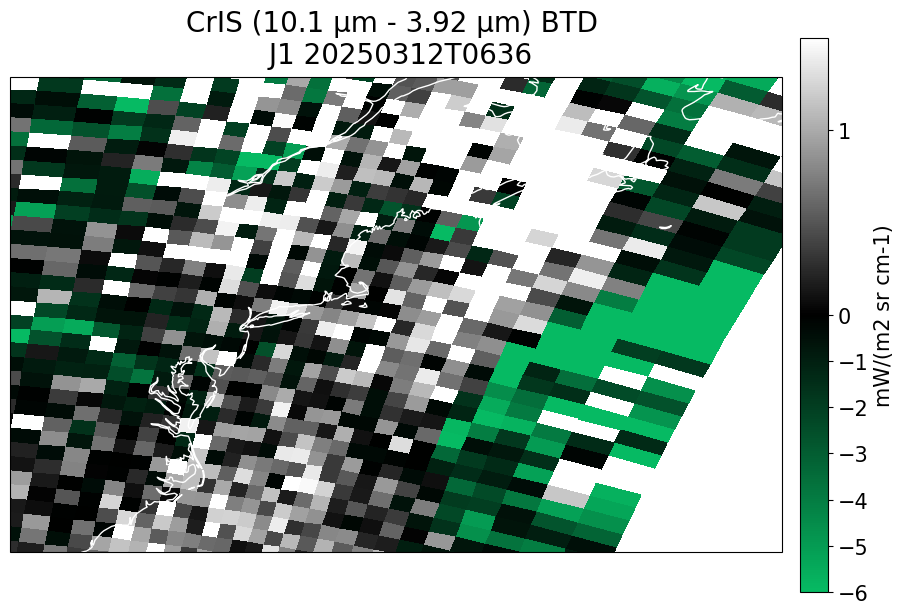

In [102]:
print(f"Plotting CrIS radiance...")
projection=ccrs.PlateCarree(central_longitude=0)
fig,ax=plt.subplots(1, figsize=(12,12),subplot_kw={'projection': projection})

cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_cmap",
    [(0, "#06BA63"), (0.5, "black"), (1, "white")]
)
norm = mcolors.TwoSlopeNorm(vmin=-6, vcenter=0, vmax=1.5)

pcm = ax.pcolormesh(da_cris['lon'], da_cris['lat'], da_cris, cmap=cmap, norm=norm, shading="nearest")

clb = plt.colorbar(pcm, ax=ax, shrink=0.6, pad=0.02)
clb.ax.tick_params(labelsize=15)
clb.set_label("mW/(m2 sr cm-1)", fontsize=15)

wl_sel_lw = round(10_000/wnum_sel_lw, 2)
wl_sel_sw = round(10_000/wnum_sel_sw, 2)
description = f"{cris_files_sample[0].split(".")[1]} {cris_files_sample[0].split(".")[3]}"
plot_title = f"CrIS ({wl_sel_lw} μm - {wl_sel_sw} μm) BTD \n {description}"
ax.set_title(plot_title, fontsize=20, pad=10)

ax.set_extent([-82, -56, 33, 49], crs=ccrs.PlateCarree())
ax.coastlines(resolution='50m', color='white', linewidth=1)

plt.savefig(f"plots/{today_date_str}_cris_spatial_{wnum_sel_lw}.png",
            dpi=200, bbox_inches='tight')
plt.show()

## Plotting spectra from a point

In [8]:
cris_dir = "data/cris/from_earthaccess/"
cris_file = "SNDR.J1.CRIS.20260305T2354.m06.g240.L1B.std.v03_08.G.260306074817.nc"
file_path = os.path.join(cris_dir, cris_file)

In [9]:
cris_target_lat = 40
cris_target_lon = -67.75

ds = c_utils.open_cris_data(file_path)
ds = c_utils.isolate_target_point(ds, target_lat=cris_target_lat, target_lon=cris_target_lon)
df_cris = c_utils.get_brightness_temperature(ds)
wl_1, Tb_1 = df_cris["Wavelength (um)"], df_cris["Brightness Temperature (K)"]

Using lat/lon of -60.31, -17.53, fov of 2


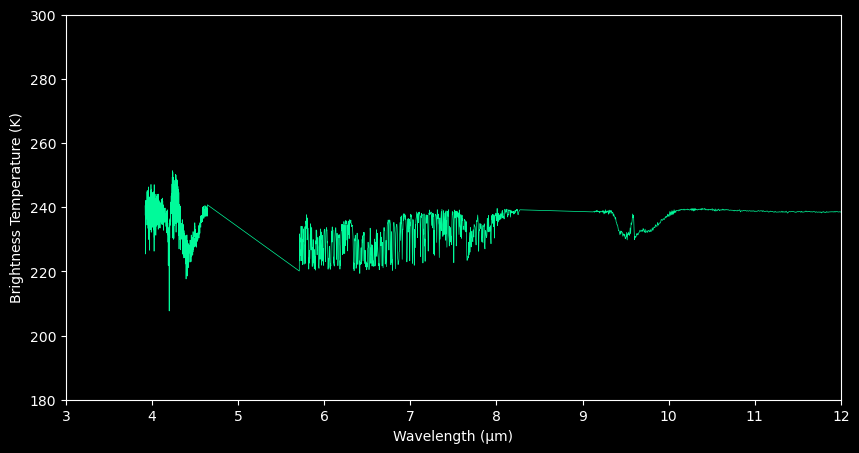

In [10]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor('black')

ax.plot(wl_1, Tb_1, 
        color="#00FA9A", 
        linewidth=0.5)
ax.set_xlim((3,12))
ax.set_ylim((180,300))

ax.set_xlabel("Wavelength (μm)")
ax.set_ylabel("Brightness Temperature (K)")

plt.savefig(f"plots/{today_date_str}_cris_spectra.png", dpi=200, bbox_inches='tight')
plt.show()

Use CrIS spectra and SRF to get brightness temperature:

In [11]:
srf_file = "data/spectral_response_functions/NPP_VIIRS_NG_RSR_M12_filtered_Oct2011f_BA.dat"

#--- flip direction to match to SRF
spectra_wl = df_cris['Wavelength (um)'][::-1]
spectra_t = df_cris['Brightness Temperature (K)'][::-1]

#--- Load SRF, which is in wavelengths and proportions
srf = np.loadtxt(srf_file)
srf_wl = np.array(srf[:, 0]/1000) # Convert from nm to µm
srf_response = np.array(srf[:, 1])

#--- Interpolate Tb onto the SRF wavelength grid
from scipy.interpolate import interp1d
interp_rad = interp1d(spectra_wl, spectra_t, kind='linear', bounds_error=False, fill_value=np.nan)
Tb_array = interp_rad(srf_wl)

#--- Remove missing data from SRF arrays
mask = ~np.isnan(Tb_array)
Tb_array = Tb_array[mask]
srf_response = srf_response[mask]
srf_wl = srf_wl[mask]

#------ Trapezoid method to get Tb multiplied by normalized SRF
Tb = np.trapezoid(Tb_array * srf_response, srf_wl) / np.trapezoid(srf_response, srf_wl) 
print(f"Brightness temperature: {Tb:.2f} K")

Brightness temperature: 238.72 K


## Plot a CrIS block

*Does not work currently*

In [12]:
ds = c_utils.open_cris_data("data/cris/from_earthaccess/SNDR.J1.CRIS.20260306T0024.m06.g005.L1B.std.v03_08.G.260306075422.nc")

IndexError: too many indices for array: array is 1-dimensional, but 4 were indexed

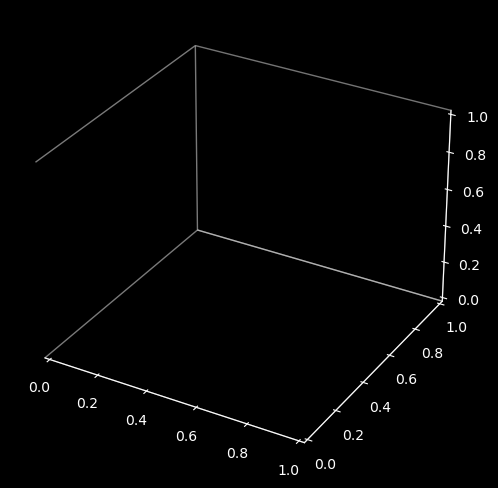

In [ ]:
import matplotlib.colors as mcolors

rad = ds['wnum_lw'].values
x = ds['xtrack'].values
y = ds['atrack'].values
z = ds['wnum_lw'].values

X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(8, 6), facecolor='black')
ax = fig.add_subplot(111, projection='3d', facecolor='black')

#--- Make background clean
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(False)

#--- Color scaling
vmin = np.min(rad)
vmax = np.max(rad)
cmap = mcolors.LinearSegmentedColormap.from_list(
            "custom_cmap",
            [(0, "#A9A9A9"), (0.5, "white"), (1, "#1167b1")]
        )
norm = mcolors.TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3)

#--- Plot stacked slices
set_min = 150 # Customizing the appearance of the stack
set_max = 550
for i in range(set_min,set_max):
    rad_i = rad[:,:,0,i]

    ax.contourf(
        X, Y, rad_i,
        levels=10,
        zdir='z',
        offset=z[i],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
        ) 

#--- Viewing angle
ax.set_zlim(z[set_min], z[set_max])
ax.view_init(elev=25, azim=-60)

plt.savefig(f"plots/{today_date_str}_cris_block.png", dpi=200, bbox_inches='tight')
plt.show()